### Training support: Clustering Analysis (K-Means)

### 1) What is clustering?
Clustering is an unsupervised learning method. It groups observations that are similar to one another without using a target variable.

In simple words:
- we do not tell the model the correct class in advance,
- the algorithm looks for natural groups in the data,
- observations inside the same group are similar,
- observations in different groups are different.

Examples:
- grouping customers with similar purchase behavior,
- identifying types of plants from their measurements,
- separating market segments,
- detecting abnormal points in data.

### 2) Why clustering is useful
Clustering helps to:
- discover hidden structures in the data,
- segment customers or products,
- summarize large datasets,
- prepare data before supervised models,
- identify patterns that are not obvious in raw data.

### 3) Key words and expressions
- Clustering = regroupement
- Unsupervised learning = apprentissage non supervisé
- Similarity = similarité
- Distance = distance
- Centroid = centre de cluster
- K-Means = méthode de regroupement par centres
- Elbow method = méthode du coude
- Standardization = normalisation / standardisation
- Cluster = groupe
- Inertia = somme des carrés intra-cluster

### 4) Main idea of K-Means
K-Means works by:
1. choosing K initial centers,
2. assigning each point to the nearest center,
3. recalculating the center of each cluster,
4. repeating the process until the centers no longer move much.

The idea is to minimize the distance between data points and the center of their cluster.

### 5) Why we standardize the data
K-Means uses distances. If one feature is measured on a very large scale and another on a small scale, the large-scale feature may dominate the clustering.

That is why we use StandardScaler:
- it transforms each feature to mean 0 and variance 1,
- it gives fair importance to all variables,
- it improves the quality of the clustering.

### 6) How to choose the number of clusters K
A very common approach is the elbow method.

The principle:
- compute K-Means for several values of K,
- plot the inertia against K,
- look for the point where the curve starts to flatten,
- that point is usually the best K.

This is called the elbow.

### 7) Interpretation of a cluster
After clustering, each observation is assigned to a cluster. We interpret the cluster by looking at:
- the average values of its features,
- the patterns among points,
- the density of the group,
- whether clusters match a real business meaning.

### 8) Typical workflow
A standard clustering workflow is:
1. load the dataset,
2. select the numeric variables,
3. standardize the data,
4. choose K,
5. apply K-Means,
6. visualize the clusters,
7. interpret and explain the results.

### 9) Important reminder
Clustering does not provide labels like a classification model. It discovers structure from the data itself.
That means the result is useful only if the clusters are meaningful and interpretable.

### 10) Example sentence for the report
> Clustering analysis was used to group similar observations based on their feature similarities. The dataset was standardized before applying K-Means, and the elbow method was used to determine the optimal number of clusters. The resulting clusters were then visualized and interpreted according to the most important variables.

---

### Practical example with the Iris dataset
The Iris dataset is a classic example for clustering because it contains different flower species with measurable features.
We can apply K-Means and determine the number of clusters using the elbow method.


In [4]:
import sys
from pathlib import Path
import pandas as pd
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
# Existing project root when it is valid; otherwise locate it.
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = next(
        (
            path
            for path in [Path.cwd(), *Path.cwd().parents]
            if (path / "src").is_dir()
        ),
        None,
    )

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project root containing 'src'.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


CLEAN_DIR = PROJECT_ROOT / "data/cleaned_data"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Projet : {PROJECT_ROOT}")
print(f"Cleaned files : {len(list(CLEAN_DIR.rglob('*.csv')))}")

Projet : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis
Cleaned files : 5


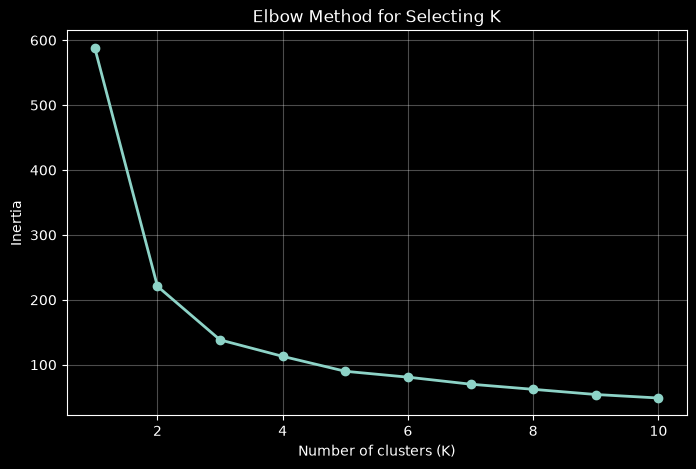

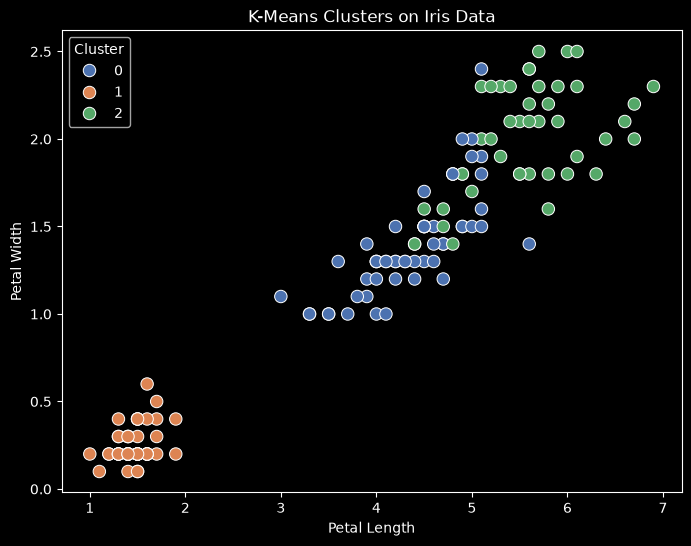

Cluster labels assigned:
0    52
1    48
2    47
Name: count, dtype: int64

Interpretation:
- Each cluster groups observations with similar flower measurements.
- The elbow method helps choose an appropriate number of groups.
- Standardization is essential because K-Means depends on distance.


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Load a well-known clustering example
iris = pd.read_csv(CLEAN_DIR/'c_iris.csv')

# Keep only numeric features
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = iris[features].copy()

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', linewidth=2)
plt.title('Elbow Method for Selecting K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.show()

# Apply K-Means with the chosen K
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Create a 2D visualization using the first two features
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X['petal_length'],
    y=X['petal_width'],
    hue=clusters,
    palette='deep',
    s=80
)
plt.title('K-Means Clusters on Iris Data')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend(title='Cluster')
plt.show()

print('Cluster labels assigned:')
print(pd.Series(clusters).value_counts().sort_index())
print('\nInterpretation:')
print('- Each cluster groups observations with similar flower measurements.')
print('- The elbow method helps choose an appropriate number of groups.')
print('- Standardization is essential because K-Means depends on distance.')
